In [19]:
import matplotlib.pyplot as plt
import PcmPy as pcm
from Plot import save_figure_incremental, make_axes_square
import os
import globals as gl
import pickle
import numpy as np

plt.style.use('default')

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/planning_models_1.svg


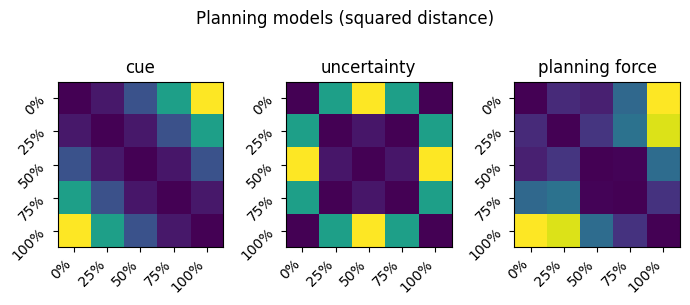

In [28]:
experiment = 'smp2'

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm12.pkl'), 'rb')
M = pickle.load(f)

vmin, vmax=-4, 4

D, G, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null') & (m.name != 'equal distance'):
        D.append(pcm.G_to_dist(m.G))
        G.append(m.G)
        name.append(m.name)
    # if isinstance(m, pcm.ComponentModel):
    #     D.append(pcm.G_to_dist(m.Gc.sum(axis=0)))
    #     name.append(m.name)

fig, axs = plt.subplots(1, len(D), figsize=(7, 3), )

for i, (g, d, n) in enumerate(zip(G, D, name)):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    axs[i].imshow(d, )
    mds, _ = pcm.classical_mds(g)

    # sizes = np.array([40, 60, 80, 100, 120])
    # axs[1, i].scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[:5][::-1], s=sizes[::-1], alpha=.3, edgecolors='none')
    axs[i].set_title(n)

    axs[i].set_xticks(np.arange(5))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')
    axs[i].set_yticks(np.arange(5))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')

    # axs[1, i].set_xticks([])
    # axs[1, i].set_yticks([])
    # lims = np.array([mds.min(), mds.max()])
    # axs[1, i].set_xlim(lims + .1 * lims)
    # axs[1, i].set_ylim(lims)
    # axs[1, i].set_aspect('equal', adjustable='box')

fig.suptitle('Planning models (squared distance)')
fig.tight_layout()

save_figure_incremental(fig, 'planning_models')

plt.show()



Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/execution_models_12.svg


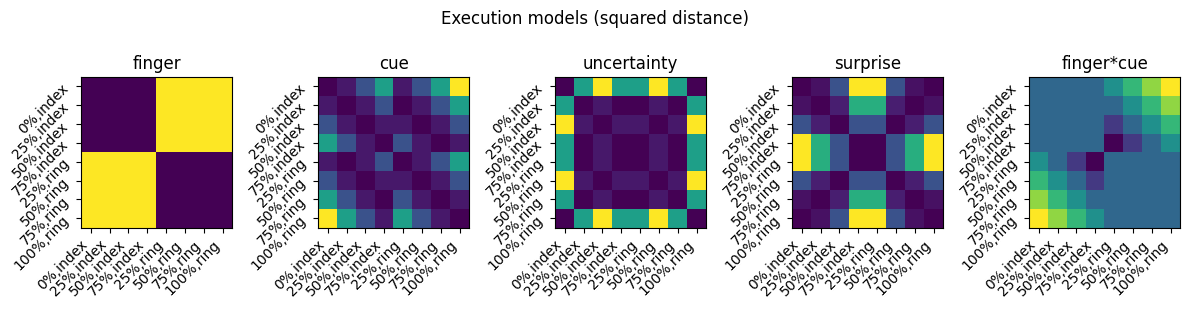

In [21]:
experiment = 'smp2'
glm = 12

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.force.exec.p'), 'rb')
M = pickle.load(f)

G, D, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G))
        G.append(m.G)
        name.append(m.name)
    if isinstance(m, pcm.FeatureModel):
        Gg = m.Ac[0] @ m.Ac[-1].T
        G.append(Gg)
        D.append(pcm.G_to_dist(Gg))
        name.append('finger*cue')

fig, axs = plt.subplots(1, len(D), figsize=(12, 3))

for i, (g, d, n) in enumerate(zip(G, D, name)):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    axs[i].imshow(d, )
    mds, _ = pcm.classical_mds(g)

    # sizes = np.array([40, 60, 80, 100, 60, 80, 100, 120])
    # axs[1, i].scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[5:13], s=sizes, alpha=.3, edgecolors='none')

    axs[i].set_title(n)

    axs[ i].set_xticks(np.arange(8))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')
    axs[ i].set_yticks(np.arange(8))
    axs[ i].set_yticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')

    # axs[1, i].set_xticks([])
    # axs[1, i].set_yticks([])
    # lims = np.array([mds.min(), mds.max()])
    # axs[1, i].set_xlim(lims + .15 * lims)
    # axs[1, i].set_ylim(lims)
    # axs[1, i].set_aspect('equal', adjustable='box')

fig.suptitle('Execution models (squared distance)')
fig.tight_layout()

save_figure_incremental(fig, 'execution_models')

plt.show()
